# Fire Season Timing: Validation

In [1]:
'''
05_01_REG_validation.ipynb
Validation notebook for fire season timing metrics.

Are the computed metrics correct and internally consistent?

Sections:
  Section 1: Automated sanity checks   (logical consistency of all metrics)
  Section 2: Per-ecoregion profile plots (visual validation against raw daily data)
  Section 3: Bimodality flag inspection  (flag calibration and spatial pattern)
  Section 4: Summary report              (actionable CSV for analysis decisions)

No GEE connection required. Reads entirely from disk.

Inputs  : master_<RUN_LABEL>_<RUN_VERSION>.csv
          _all_daily_counts.csv
          _eco_quality.csv
          eco_geometries.json

Outputs : plots/profile_plots/<ECO_ID>_<ECO_NAME>_climatology.png
          _validation_summary.csv
'''

import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

warnings.filterwarnings('ignore')
print('Libraries loaded.')


Libraries loaded.


In [4]:
# RUN CONFIGURATION -------------------------------------------------------------------------------
# Match these to the pipeline run you want to validate.

RUN_LABEL   = 'med_basin'
RUN_VERSION = 'v3'

# Windows path file
# BASE_OUT_DIR = r'C:\Users\ibekar\Documents\GitProjects\TGPF'
# Mac path file
BASE_OUT_DIR = "/Users/ibekar/Github/TGPF"

# Derived paths: do not edit below this line
_run_name   = f'{RUN_LABEL}_{RUN_VERSION}'
output_dir  = os.path.join(BASE_OUT_DIR, 'outputs', _run_name)
daily_dir   = os.path.join(output_dir, 'daily_counts')
plots_dir = os.path.join(output_dir, 'plots')
profile_dir = os.path.join(plots_dir, 'profile_plots')

os.makedirs(plots_dir, exist_ok=True)
os.makedirs(profile_dir, exist_ok=True)

# BIMODALITY THRESHOLDS: must match values used in pipeline ----------------------
BC_THRESHOLD     = 0.555

# PLOT STYLE ----------------------------------------------------------------------
C_ONSET  = '#2ca02c'
C_PEAK   = '#d62728'
C_MEDIAN = '#ff7f0e'
C_CONC   = '#aec7e8'
C_FLAGS  = {0: '#1f77b4', 1: '#d62728'}
L_FLAGS  = {0: 'Clean (0)', 1: 'Flagged (1)'}
FIG_DPI  = 150

# Month start DOYs and labels for x-axis ticks (non-leap year)
MONTH_STARTS = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
MONTH_NAMES  = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(f'Run       : {_run_name}')
print(f'Output dir: {output_dir}')
print(f'Plots dir: {plots_dir}')
print(f'Profiles  : {profile_dir}')

Run       : med_basin_v3
Output dir: /Users/ibekar/Github/TGPF/outputs/med_basin_v3
Plots dir: /Users/ibekar/Github/TGPF/outputs/med_basin_v3/plots
Profiles  : /Users/ibekar/Github/TGPF/outputs/med_basin_v3/plots/profile_plots


## Load Data

In [5]:
# LOAD DATA ---------------------------------------------------------------------------------------

master_path  = os.path.join(output_dir, f'master_{_run_name}.csv')
daily_path   = os.path.join(output_dir, '_all_daily_counts.csv')
quality_path = os.path.join(output_dir, '_eco_quality.csv')
geo_path     = os.path.join(output_dir, 'eco_geometries.json')

master_df  = pd.read_csv(master_path)
daily_df   = pd.read_csv(daily_path)
quality_df = pd.read_csv(quality_path)

with open(geo_path, 'r') as f:
    geo_data = json.load(f)

# Geometry lookup: eco_id → GeoJSON geometry dict (used in map plot)
geo_lookup = {rec['eco_id']: rec['geometry'] for rec in geo_data}

# Ecoregion reference table: one stable row per ecoregion
eco_ref = master_df.groupby('eco_id').agg(
    eco_name  = ('eco_name',   'first'),
    biome_num = ('biome_num',  'first'),
    biome_name= ('biome_name', 'first'),
).reset_index()

n_eco  = master_df['eco_id'].nunique()
n_rows = len(master_df)


print('Columns in master CSV:')
for col in master_df.columns:
    print(f'  {col}')
print()
print(f'Master CSV : {n_rows} rows: {n_eco} ecoregions')
print(f'Daily CSV  : {len(daily_df)} rows')
print(f'Quality CSV: {len(quality_df)} ecoregions')
print(f'Geometries : {len(geo_data)} ecoregions')


Columns in master CSV:
  eco_id
  eco_name
  biome_num
  biome_name
  year
  onset_doy
  peak_doy
  end_doy
  season_length
  n_detections
  onset_month
  peak_month
  onset_doy_10
  end_doy_90
  onset_doy_15
  end_doy_85
  median_doy
  mean_median_div
  q25_doy
  q75_doy
  iqr_season_length
  active_days
  peak_concentration
  skewness
  kurtosis_raw
  bc
  bimodal_flag_year
  peak_outside_window
  n_years_valid
  pct_years_valid
  cv_peak_doy
  mean_profile_corr
  frac_flagged
  bimodal_flag_eco

Master CSV : 1301 rows: 58 ecoregions
Daily CSV  : 495659 rows
Quality CSV: 58 ecoregions
Geometries : 59 ecoregions


## Section 1: Sanity Checks

In [153]:
# SANITY CHECKS -------------------------------------------------------------------------

checks     = []
fail_index = set()

def add_check(name, mask, description):
    n_total = len(master_df)
    n_pass  = int(mask.sum())
    n_fail  = n_total - n_pass
    rate    = n_pass / n_total * 100
    status  = 'PASS' if n_fail == 0 else 'WARN'
    checks.append({
        'Check'      : name,
        'Description': description,
        'Pass'       : n_pass,
        'Fail'       : n_fail,
        'Rate %'     : round(rate, 1),
        'Status'     : status,
    })
    if n_fail > 0:
        failing = master_df[~mask]
        for _, row in failing.iterrows():
            fail_index.add((row['eco_id'], row['year']))
        print(f'  WARN [{name}]: {n_fail} failures. First 5:')
        print(failing[['eco_id', 'eco_name', 'year']].head(5).to_string(index=False))
        print()

# --- Logical ordering of primary metrics ------------------------------------------
add_check(
    'onset_doy < end_doy',
    master_df['onset_doy'] < master_df['end_doy'],
    'Onset DOY must precede end DOY'
)
add_check(
    'season_length > 0',
    master_df['season_length'] > 0,
    'Season length must be positive'
)
add_check(
    'active_days >= 0',
    master_df['active_days'] >= 0,
    'Active days cannot be negative'
)
add_check(
    'active_days <= season_length',
    master_df['active_days'] <= master_df['season_length'],
    'Active days cannot exceed season length'
)
add_check(
    'peak_outside_window consistent',
    (
        (master_df['peak_outside_window'] == 0) &
        (master_df['peak_doy'] >= master_df['onset_doy']) &
        (master_df['peak_doy'] <= master_df['end_doy'])
    ) | (master_df['peak_outside_window'] == 1),
    'peak_outside_window flag must agree with onset/peak/end values'
)

# --- Bounded metrics --------------------------------------------------------------
add_check(
    'concentration in [0, 1]',
    (master_df['peak_concentration'] >= 0) & (master_df['peak_concentration'] <= 1),
    'Peak concentration must be between 0 and 1'
)

# --- Alternative thresholds bracket primary thresholds ----------------------------
add_check(
    'onset_10 >= onset_5',
    master_df['onset_doy_10'].fillna(master_df['onset_doy']) >= master_df['onset_doy'],
    '10% onset must be >= 5% onset'
)
add_check(
    'onset_15 >= onset_10',
    master_df['onset_doy_15'].fillna(master_df['onset_doy_10']) >=
    master_df['onset_doy_10'].fillna(master_df['onset_doy']),
    '15% onset must be >= 10% onset'
)
add_check(
    'end_90 <= end_95',
    master_df['end_doy_90'].fillna(master_df['end_doy']) <= master_df['end_doy'],
    '90% end must be <= 95% end'
)
add_check(
    'end_85 <= end_90',
    master_df['end_doy_85'].fillna(master_df['end_doy_90']) <=
    master_df['end_doy_90'].fillna(master_df['end_doy']),
    '85% end must be <= 90% end'
)

# --- IQR season length vs primary -------------------------------------------------
iqr_valid = master_df['iqr_season_length'].notna()
add_check(
    'iqr_length <= season_length',
    (~iqr_valid) | (master_df['iqr_season_length'] <= master_df['season_length']),
    'IQR season length must not exceed primary season length'
)

# --- Flag values ------------------------------------------------------------------
add_check(
    'bimodal_flag_year valid',
    master_df['bimodal_flag_year'].isin([0, 1]),
    'Per-year bimodal flag must be 0 or 1'
)
add_check(
    'bimodal_flag_eco valid',
    master_df['bimodal_flag_eco'].isin([0, 1]),
    'Ecoregion bimodal flag must be 0 or 1'
)

# --- Detection threshold ----------------------------------------------------------
add_check(
    'n_detections >= 20',
    master_df['n_detections'] >= 20,
    'All rows in master CSV should have passed MIN_DETECTIONS = 20'
)

# --- Print summary table ----------------------------------------------------------
print()
print('=' * 76)
print('SANITY CHECK SUMMARY')
print('=' * 76)
checks_df = pd.DataFrame(checks)
print(checks_df[['Check', 'Pass', 'Fail', 'Rate %', 'Status']].to_string(index=False))
print('=' * 76)
n_warn = sum(1 for c in checks if c['Status'] == 'WARN')
print(f'\n{len(checks)} checks: {len(checks) - n_warn} PASS, {n_warn} WARN')
print(f'{len(fail_index)} ecoregion-years involved in at least one failure.')


SANITY CHECK SUMMARY
                         Check  Pass  Fail  Rate % Status
           onset_doy < end_doy  1301     0   100.0   PASS
             season_length > 0  1301     0   100.0   PASS
              active_days >= 0  1301     0   100.0   PASS
  active_days <= season_length  1301     0   100.0   PASS
peak_outside_window consistent  1301     0   100.0   PASS
       concentration in [0, 1]  1301     0   100.0   PASS
           onset_10 >= onset_5  1301     0   100.0   PASS
          onset_15 >= onset_10  1301     0   100.0   PASS
              end_90 <= end_95  1301     0   100.0   PASS
              end_85 <= end_90  1301     0   100.0   PASS
   iqr_length <= season_length  1301     0   100.0   PASS
       bimodal_flag_year valid  1301     0   100.0   PASS
        bimodal_flag_eco valid  1301     0   100.0   PASS
            n_detections >= 20  1301     0   100.0   PASS

14 checks: 14 PASS, 0 WARN
0 ecoregion-years involved in at least one failure.


## Section 2: Per-Ecoregion Profile Plots

In [168]:
# SECTION 2: PER-ECOREGION PROFILE PLOTS ----------------------------------------------------------
# Main panel : per-year thin lines + smoothed mean profile
# Season bands: 5–95%, 10–90%, 15–85%, IQR as full-height shades + bottom bars
# Markers     : onset, peak, median, end as vertical lines
# Annotation  : stats box top-right corner

eco_ids = sorted(master_df['eco_id'].unique())

# ── COLOR SCHEME ──────────────────────────────────────────────────────────────
C_PROFILE = '#2c7bb6'
C_YR_LINE = '#aaaaaa'
C_ONSET   = '#2ca02c'
C_PEAK    = '#d62728'
C_MEDIAN  = '#ff7f0e'
C_END     = '#9467bd'
C_S95     = '#4393c3'
C_10      = '#74add1'
C_15      = '#abd9e9'
C_IQR     = '#f4a582'

for eco_id in eco_ids:
    eco_rows   = master_df[master_df['eco_id'] == eco_id]
    daily_rows = daily_df[daily_df['eco_id'] == eco_id].copy()

    eco_name   = eco_rows['eco_name'].iloc[0]
    biome_name = eco_rows['biome_name'].iloc[0]

    q_row    = quality_df[quality_df['eco_id'] == eco_id]
    flag_eco = int(q_row['bimodal_flag_eco'].iloc[0])    if len(q_row) else 0
    corr_eco = float(q_row['mean_profile_corr'].iloc[0]) if len(q_row) and pd.notna(q_row['mean_profile_corr'].iloc[0]) else np.nan
    cv_eco   = float(q_row['cv_peak_doy'].iloc[0])       if len(q_row) and pd.notna(q_row['cv_peak_doy'].iloc[0]) else np.nan

    # ── BUILD FULL YEAR × DOY GRID ────────────────────────────────────────────
    years     = sorted(daily_rows['year'].unique())
    full_grid = pd.MultiIndex.from_product(
        [years, range(1, 366)], names=['year', 'doy']
    ).to_frame(index=False)

    daily_full = (
        full_grid
        .merge(daily_rows[['year', 'doy', 'n_detections']], on=['year', 'doy'], how='left')
        .fillna({'n_detections': 0})
    )
    daily_full['year_total'] = daily_full.groupby('year')['n_detections'].transform('sum')
    daily_full['prop'] = np.where(
        daily_full['year_total'] > 0,
        daily_full['n_detections'] / daily_full['year_total'],
        0
    )

    # ── MEAN PROFILE ──────────────────────────────────────────────────────────
    mean_prop = daily_full.groupby('doy')['prop'].mean().values
    smoothed  = pd.Series(mean_prop).rolling(15, center=True, min_periods=1).mean().values

    # ── VALID METRIC ROWS ─────────────────────────────────────────────────────
    m_valid = eco_rows.dropna(subset=['onset_doy', 'peak_doy', 'end_doy'])

    onset_mean  = m_valid['onset_doy'].mean()          if len(m_valid) else np.nan
    peak_mean   = m_valid['peak_doy'].mean()            if len(m_valid) else np.nan
    end_mean    = m_valid['end_doy'].mean()             if len(m_valid) else np.nan
    median_mean = m_valid['median_doy'].mean()          if 'median_doy' in m_valid.columns and len(m_valid) else np.nan
    season_len  = m_valid['season_length'].mean()       if len(m_valid) else np.nan
    iqr_len     = m_valid['iqr_season_length'].mean()   if len(m_valid) else np.nan
    active_days = m_valid['active_days'].mean()         if len(m_valid) else np.nan
    peak_conc   = m_valid['peak_concentration'].mean()  if len(m_valid) else np.nan
    mm_div      = m_valid['mean_median_div'].mean()     if len(m_valid) else np.nan
    skew_val    = m_valid['skewness'].mean()            if len(m_valid) else np.nan
    bc_val      = m_valid['bc'].mean()                  if len(m_valid) else np.nan

    onset_10 = m_valid['onset_doy_10'].mean() if 'onset_doy_10' in m_valid.columns and len(m_valid) else np.nan
    end_90   = m_valid['end_doy_90'].mean()   if 'end_doy_90'   in m_valid.columns and len(m_valid) else np.nan
    onset_15 = m_valid['onset_doy_15'].mean() if 'onset_doy_15' in m_valid.columns and len(m_valid) else np.nan
    end_85   = m_valid['end_doy_85'].mean()   if 'end_doy_85'   in m_valid.columns and len(m_valid) else np.nan
    len_10   = (end_90 - onset_10)            if pd.notna(onset_10) and pd.notna(end_90)   else np.nan
    len_15   = (end_85 - onset_15)            if pd.notna(onset_15) and pd.notna(end_85)   else np.nan

    # IQR window bounds
    if 'onset_doy_25' in m_valid.columns and 'end_doy_75' in m_valid.columns:
        iqr_onset = m_valid['onset_doy_25'].mean()
        iqr_end   = m_valid['end_doy_75'].mean()
    else:
        iqr_onset = peak_mean - iqr_len / 2 if pd.notna(peak_mean) and pd.notna(iqr_len) else np.nan
        iqr_end   = peak_mean + iqr_len / 2 if pd.notna(peak_mean) and pd.notna(iqr_len) else np.nan

    # ── PLOT ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 5))
    doys = np.arange(1, 366)

    # --- Full-height season window shades (very transparent, drawn first) ---
    if pd.notna(onset_mean) and pd.notna(end_mean):
        ax.axvspan(onset_mean, end_mean, alpha=0.03, color=C_S95, zorder=0,
                   label='5–95% window')
    if pd.notna(iqr_onset) and pd.notna(iqr_end):
        ax.axvspan(iqr_onset, iqr_end, alpha=0.06, color=C_IQR, zorder=0,
                   label='IQR window')

    # --- Per-year thin lines ---
    for yr in years:
        yr_prop = daily_full[daily_full['year'] == yr]['prop'].values
        if len(yr_prop) == 365:
            yr_smooth = pd.Series(yr_prop).rolling(15, center=True, min_periods=1).mean().values
            ax.plot(doys, yr_smooth, color=C_YR_LINE, linewidth=0.5, alpha=0.35, zorder=1)

    # --- Mean profile ---
    ax.plot(doys, smoothed, color=C_PROFILE, linewidth=2.2, zorder=3, label='Mean profile')

    # --- Vertical markers ---
    marker_kw = dict(zorder=4, linewidth=1.4)
    if pd.notna(onset_mean):
        ax.axvline(onset_mean,  color=C_ONSET,  label='Onset (5%)',  **marker_kw)
    if pd.notna(peak_mean):
        ax.axvline(peak_mean,   color=C_PEAK,   label='Peak',        **marker_kw)
    if pd.notna(median_mean):
        ax.axvline(median_mean, color=C_MEDIAN, label='Median',
                   linestyle='--', **marker_kw)
    if pd.notna(end_mean):
        ax.axvline(end_mean,    color=C_END,    label='End (95%)',   **marker_kw)

    # --- Bottom bars ---
    bar_h    = smoothed.max() * 0.04
    bar_step = smoothed.max() * 0.07

    season_bars = [
        (onset_mean, end_mean,  season_len, C_S95, '5–95%'),
        (onset_10,   end_90,    len_10,     C_10,  '10–90%'),
        (onset_15,   end_85,    len_15,     C_15,  '15–85%'),
        (iqr_onset,  iqr_end,   iqr_len,    C_IQR, 'IQR'),
    ]

    for rank, (b_onset, b_end, b_len, color, label) in enumerate(season_bars):
        bar_y = smoothed.max() * -0.07 - rank * bar_step
        if pd.notna(b_onset) and pd.notna(b_end):
            ax.barh(bar_y, width=b_end - b_onset, left=b_onset,
                    height=bar_h, color=color, alpha=0.85,
                    zorder=5, clip_on=False)
            len_str = f'{b_len:.0f}d' if pd.notna(b_len) else ''
            ax.text(b_onset, bar_y, f' {label}: {len_str}',
                    va='center', fontsize=7, color=color,
                    fontweight='bold', zorder=6, clip_on=False)

    # --- Annotation box (top-right) ---
    flag_str = '⚑ Flagged' if flag_eco == 1 else 'Clean'
    bc_str   = f'{bc_val:.3f}  {flag_str}' if pd.notna(bc_val) else f'—  {flag_str}'

    def fmt(val, decimals=1, suffix=''):
        return f'{val:.{decimals}f}{suffix}' if pd.notna(val) else '—'

    stats_lines = [
        ('Season length',  fmt(season_len,  1, ' d')),
        ('IQR season',     fmt(iqr_len,     1, ' d')),
        ('10% season',     fmt(len_10,      1, ' d')),
        ('15% season',     fmt(len_15,      1, ' d')),
        ('Active days',    fmt(active_days, 1, ' d')),
        ('Peak conc.',     fmt(peak_conc,   3)),
        ('Mean–med div.',  fmt(mm_div,      1, ' d')),
        ('Skewness',       fmt(skew_val,    2)),
        ('BC',             bc_str),
        ('CV peak',        fmt(cv_eco,      3)),
        ('Profile corr.',  fmt(corr_eco,    3)),
    ]

    box_text = '\n'.join(f'{k:<16} {v}' for k, v in stats_lines)
    ax.text(0.78, 0.97, box_text,
            transform=ax.transAxes,
            fontsize=7.5, family='monospace',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='#cccccc', alpha=0.92),
            zorder=7,
            clip_on=True)

    # --- Axes ---
    ax.set_xlim(1, 365)
    ax.set_xticks(MONTH_STARTS)
    ax.set_xticklabels(MONTH_NAMES)
    ax.set_ylabel('Proportion of annual detections')
    ax.set_xlabel('Day of year')
    ax.grid(axis='y', alpha=0.2, linewidth=0.5)
    ax.spines[['top', 'right']].set_visible(False)

    # --- Title ---
    ax.set_title(
        f'{eco_name}  (ID: {eco_id})\n'
        f'Biome: {biome_name}  |  n = {len(years)} years',
        fontsize=10, fontweight='bold'
    )

    ax.legend(fontsize=7.5, ncol=4, frameon=False,
              loc='upper left', bbox_to_anchor=(0, 1.0))

    fig.subplots_adjust(bottom=0.22)
    plt.tight_layout()

    safe_name = eco_name.replace(' ', '_').replace('/', '_')
    save_path = os.path.join(profile_dir, f'{eco_id}_{safe_name}_climatology.png')
    plt.savefig(save_path, dpi=FIG_DPI, bbox_inches='tight')
    plt.close()

print(f'Saved {len(eco_ids)} profile plots to {profile_dir}')

Saved 58 profile plots to C:\Users\ibekar\Documents\GitProjects\TGPF\outputs\med_basin_v3\plots\profile_plots


## Section 3: Bimodality Flag Inspection

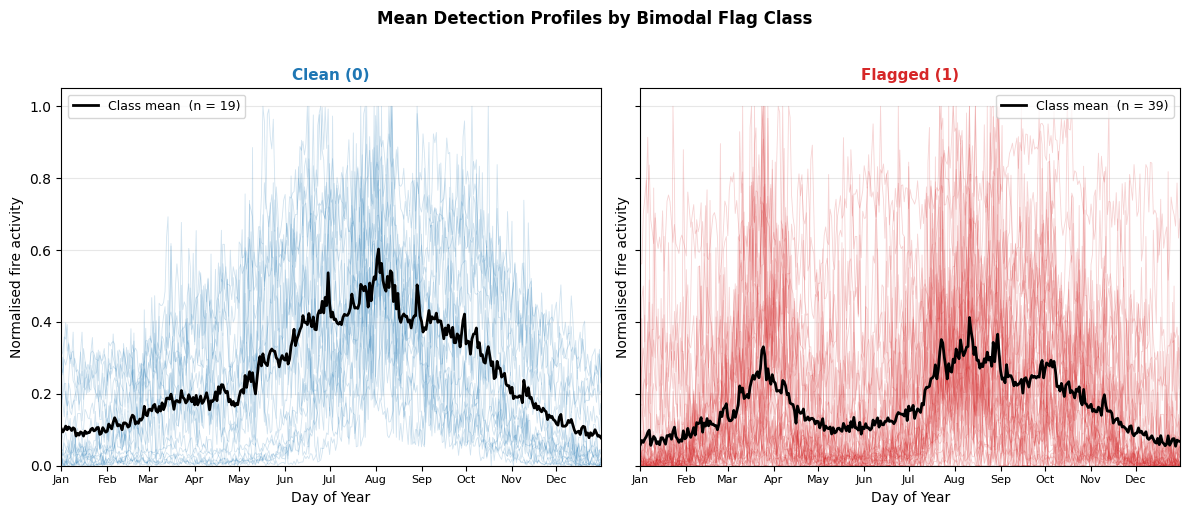

In [175]:
# PLOT 01 — MEAN DETECTION PROFILES BY BIMODAL FLAG CLASS ----------------------------------------
DOY_RANGE = list(range(1, 366))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.suptitle('Mean Detection Profiles by Bimodal Flag Class',
             fontsize=12, fontweight='bold', y=1.02)

for flag_val, ax in zip([0, 1], axes):

    eco_ids_class = quality_df[quality_df['bimodal_flag_eco'] == flag_val]['eco_id'].values
    all_profiles  = []

    for eco_id in eco_ids_class:
        eco_daily = daily_df[daily_df['eco_id'] == eco_id]
        if eco_daily.empty:
            continue

        pivot = eco_daily.pivot_table(
            index='year', columns='doy',
            values='n_detections', fill_value=0
        ).reindex(columns=DOY_RANGE, fill_value=0)

        mean_prof = pivot.mean(axis=0).values.astype(float)
        max_val   = mean_prof.max()
        if max_val == 0:
            continue

        norm_prof = mean_prof / max_val
        ax.plot(DOY_RANGE, norm_prof, color=C_FLAGS[flag_val],
                alpha=0.20, linewidth=0.6)
        all_profiles.append(norm_prof)

    if all_profiles:
        class_mean = np.mean(all_profiles, axis=0)
        ax.plot(DOY_RANGE, class_mean, color='black', linewidth=2.0,
                label=f'Class mean  (n = {len(all_profiles)})')
        ax.legend(fontsize=9)

    ax.set_xticks(MONTH_STARTS)
    ax.set_xticklabels(MONTH_NAMES, fontsize=8)
    ax.set_xlim(1, 365)
    ax.set_ylim(0, 1.05)
    ax.set_title(L_FLAGS[flag_val], fontsize=11,
                 fontweight='bold', color=C_FLAGS[flag_val])
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Normalised fire activity')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '98_profiles_by_flag_class.png'),
            dpi=FIG_DPI, bbox_inches='tight')
plt.show()

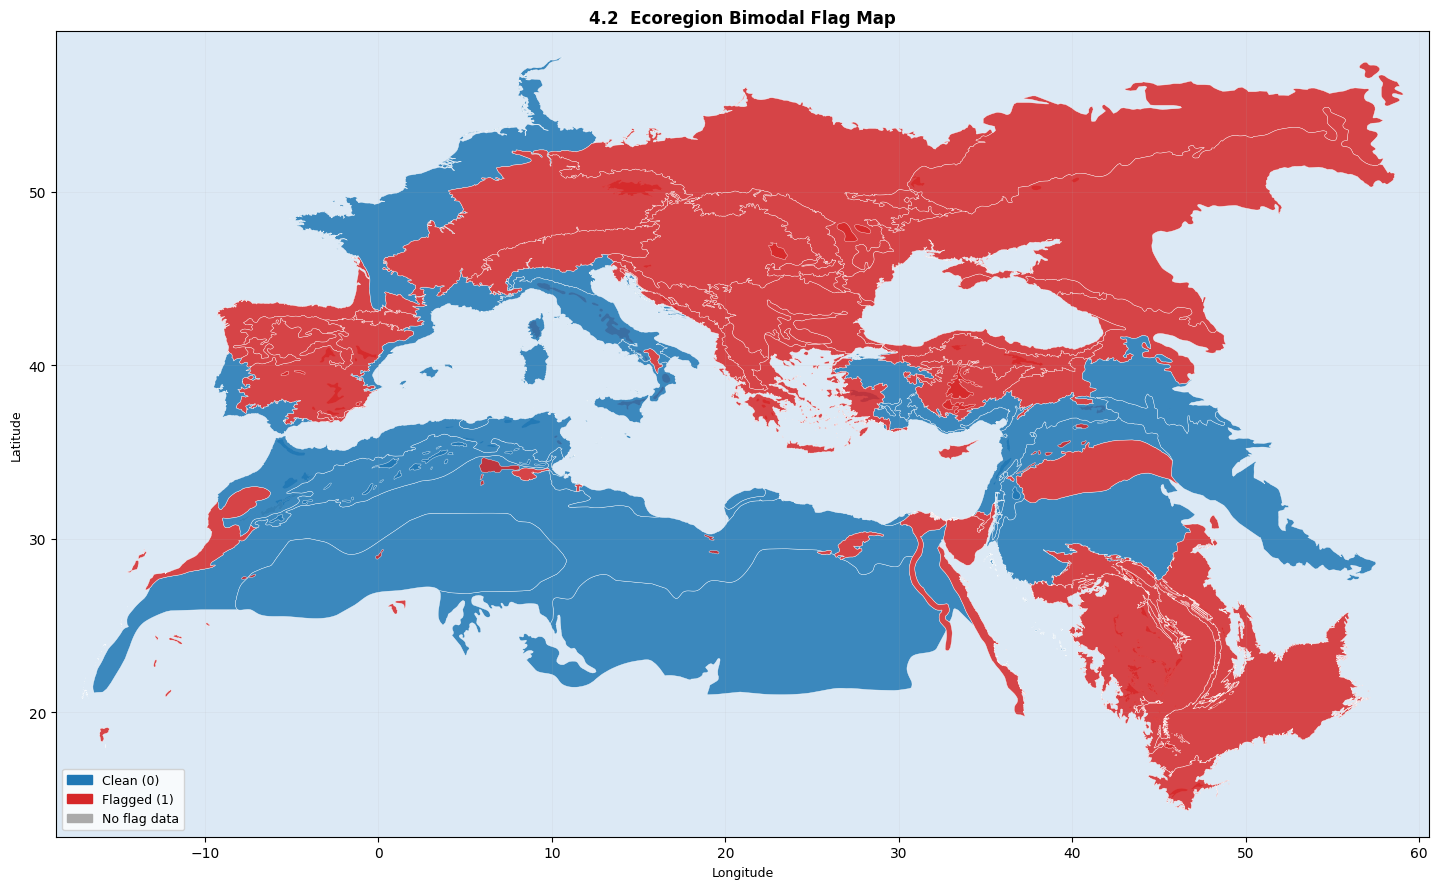

In [176]:
# PLOT 02 — ECOREGION BIMODAL FLAG MAP ------------------------------------------------------------
# Polygon patches drawn from eco_geometries.json. No GEE or geopandas required.
# Handles both Polygon and MultiPolygon geometry types.
# Color: blue=clean, red=flagged, grey=no flag data.

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_facecolor('#dce9f5')
fig.patch.set_facecolor('white')

flag_lookup = quality_df.set_index('eco_id')['bimodal_flag_eco'].to_dict()

def extract_rings(geometry):
    '''Return a list of coordinate rings from a GeoJSON Polygon or MultiPolygon.'''
    geo_type = geometry.get('type', '')
    coords   = geometry.get('coordinates', [])
    if geo_type == 'Polygon':
        return [coords[0]] if coords else []
    elif geo_type == 'MultiPolygon':
        return [poly[0] for poly in coords if poly]
    return []

all_patches = []
all_lons    = []
all_lats    = []

for eco_id, geometry in geo_lookup.items():
    flag_val = flag_lookup.get(eco_id, -1)
    color    = C_FLAGS.get(flag_val, '#aaaaaa')

    for ring in extract_rings(geometry):
        if len(ring) < 3:
            continue
        xy = [(pt[0], pt[1]) for pt in ring]
        all_lons += [pt[0] for pt in xy]
        all_lats += [pt[1] for pt in xy]
        patch = Polygon(xy, closed=True,
                        facecolor=color, edgecolor='white',
                        linewidth=0.3, alpha=0.85)
        all_patches.append(patch)
        ax.add_patch(patch)

if all_lons and all_lats:
    pad = 1.5
    ax.set_xlim(min(all_lons) - pad, max(all_lons) + pad)
    ax.set_ylim(min(all_lats) - pad, max(all_lats) + pad)

ax.set_aspect('equal')
ax.set_xlabel('Longitude', fontsize=9)
ax.set_ylabel('Latitude', fontsize=9)
ax.set_title('4.2  Ecoregion Bimodal Flag Map',
             fontsize=12, fontweight='bold')

legend_handles = [
    mpatches.Patch(color=C_FLAGS[k], label=L_FLAGS[k]) for k in sorted(C_FLAGS)
] + [mpatches.Patch(color='#aaaaaa', label='No flag data')]
ax.legend(handles=legend_handles, loc='lower left', fontsize=9)
ax.grid(alpha=0.2, linewidth=0.4)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '99_bimodal_flag_map.png'),
            dpi=FIG_DPI, bbox_inches='tight')
plt.show()

## Section 4: Summary Report

In [174]:
# SUMMARY REPORT ----------------------------------------------------------------------------------

try:
    _ = fail_index
except NameError:
    fail_index = set()
    print('Warning: Section 1 (sanity checks) was not run.')
    print('         any_sanity_fail will be False for all ecoregions.')
    print()

fail_eco_ids = {eco_id for (eco_id, _yr) in fail_index}

summary_rows = []

for _, q_row in quality_df.iterrows():
    eco_id = q_row['eco_id']

    ref        = eco_ref[eco_ref['eco_id'] == eco_id]
    eco_name   = ref['eco_name'].iloc[0]   if len(ref) else ''
    biome_name = ref['biome_name'].iloc[0] if len(ref) else ''

    rows_eco        = master_df[master_df['eco_id'] == eco_id]
    n_years_valid   = int(rows_eco['n_years_valid'].iloc[0])    if len(rows_eco) else 0
    pct_years_valid = float(rows_eco['pct_years_valid'].iloc[0]) if len(rows_eco) else 0.0

    flag_eco        = int(q_row['bimodal_flag_eco'])
    frac_flagged    = float(q_row['frac_flagged'])
    mean_corr       = float(q_row['mean_profile_corr']) \
                      if pd.notna(q_row['mean_profile_corr']) else None
    cv_peak         = float(q_row['cv_peak_doy']) \
                      if pd.notna(q_row['cv_peak_doy'])       else None
    any_sanity_fail = eco_id in fail_eco_ids

    if any_sanity_fail:
        status = 'CHECK'
    elif flag_eco == 1:
        status = 'FLAGGED'
    else:
        status = 'CLEAN'

    summary_rows.append({
        'eco_id'            : eco_id,
        'eco_name'          : eco_name,
        'biome_name'        : biome_name,
        'n_years_valid'     : n_years_valid,
        'pct_years_valid'   : pct_years_valid,
        'mean_profile_corr' : mean_corr,
        'cv_peak_doy'       : cv_peak,
        'bimodal_flag_eco'  : flag_eco,
        'frac_flagged'      : frac_flagged,
        'any_sanity_fail'   : int(any_sanity_fail),
        'recommended_status': status,
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = os.path.join(output_dir, '_validation_summary.csv')
summary_df.to_csv(summary_path, index=False)

print(summary_df[[
    'eco_id', 'eco_name', 'n_years_valid',
    'bimodal_flag_eco', 'recommended_status'
]].to_string(index=False))

print('=' * 68)
print('VALIDATION SUMMARY')
print('=' * 68)
status_counts = summary_df['recommended_status'].value_counts()
for status, count in status_counts.sort_index().items():
    pct = count / len(summary_df) * 100
    print(f'  {status:<12} : {count:>4}  ({pct:.1f}%)')
print('-' * 68)
print(f'  Total        : {len(summary_df):>4}  ecoregions')
print('=' * 68)
print()
print(f'Saved: {os.path.abspath(summary_path)}')
print()

 eco_id                                                          eco_name  n_years_valid  bimodal_flag_eco recommended_status
  644.0                                Appenine deciduous montane forests             14                 1            FLAGGED
  646.0                                              Balkan mixed forests             23                 1            FLAGGED
  648.0                                          Cantabrian mixed forests             23                 1            FLAGGED
  650.0                                            Caucasus mixed forests             23                 1            FLAGGED
  652.0                            Central Anatolian steppe and woodlands             23                 1            FLAGGED
  654.0                                    Central European mixed forests             23                 1            FLAGGED
  658.0                           Crimean Submediterranean forest complex             23                 1            